In [176]:
from automata.fa.dfa import DFA
from automata.fa.nfa import NFA

In [177]:
regex_string = "[+|-|=]|[a-z A-Z]+[0-9]*|[0-9]+"

In [178]:
nfa_lexer = NFA.from_regex(regex_string)

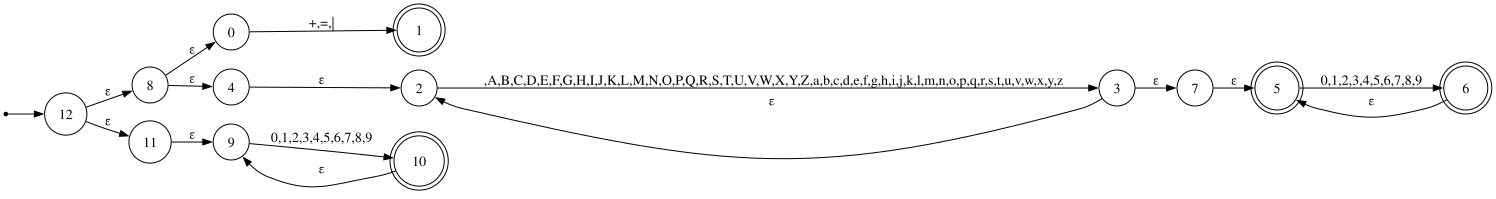

In [179]:
nfa_lexer.show_diagram(path="automata_pics/lexer_nfa.png")

In [180]:
nfa_lexer.accepts_input("=")

True

In [181]:
print(nfa_lexer.transitions)

frozendict.frozendict({0: frozendict.frozendict({'+': frozenset({1}), '=': frozenset({1}), '|': frozenset({1})}), 1: frozendict.frozendict({}), 2: frozendict.frozendict({'f': frozenset({3}), 'B': frozenset({3}), 'g': frozenset({3}), 'M': frozenset({3}), 'Q': frozenset({3}), 'D': frozenset({3}), 'h': frozenset({3}), 'n': frozenset({3}), 'z': frozenset({3}), 'P': frozenset({3}), 'c': frozenset({3}), 'C': frozenset({3}), 'y': frozenset({3}), 'Y': frozenset({3}), ' ': frozenset({3}), 'E': frozenset({3}), 'X': frozenset({3}), 'o': frozenset({3}), 'R': frozenset({3}), 'u': frozenset({3}), 'v': frozenset({3}), 'L': frozenset({3}), 'O': frozenset({3}), 'J': frozenset({3}), 'W': frozenset({3}), 'e': frozenset({3}), 'F': frozenset({3}), 'b': frozenset({3}), 'q': frozenset({3}), 'Z': frozenset({3}), 's': frozenset({3}), 'I': frozenset({3}), 't': frozenset({3}), 'S': frozenset({3}), 'r': frozenset({3}), 'w': frozenset({3}), 'K': frozenset({3}), 'p': frozenset({3}), 'd': frozenset({3}), 'i': frozen

In [182]:
dfa_lexer = DFA.from_nfa(nfa_lexer)

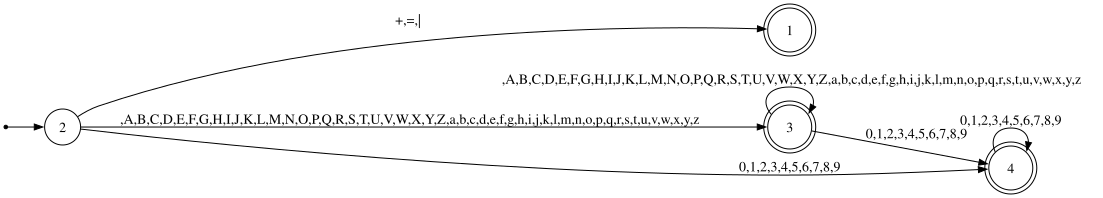

In [183]:
dfa_lexer.show_diagram(path="automata_pics/lexer_dfa.png")

In [184]:
minimized_dfa_lexer = dfa_lexer.minify()

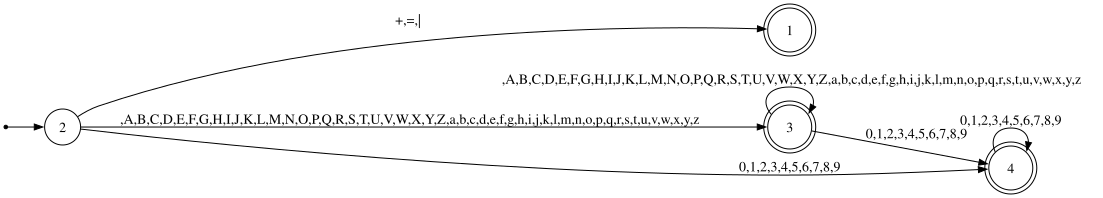

In [185]:
minimized_dfa_lexer.show_diagram(path="automata_pics/minimized_dfa_lexer.png")

In [186]:
minimized_dfa_lexer.accepts_input("hello334")

True

In [187]:
minimized_dfa_lexer.transitions

frozendict.frozendict({1: frozendict.frozendict({}), 2: frozendict.frozendict({'+': 1, '=': 1, '|': 1, 'f': 3, 'B': 3, 'g': 3, 'M': 3, 'Q': 3, 'D': 3, 'h': 3, 'n': 3, 'z': 3, 'P': 3, 'c': 3, 'C': 3, 'y': 3, 'Y': 3, ' ': 3, 'E': 3, 'X': 3, 'o': 3, 'R': 3, 'u': 3, 'v': 3, 'L': 3, 'O': 3, 'J': 3, 'W': 3, 'e': 3, 'F': 3, 'b': 3, 'q': 3, 'Z': 3, 's': 3, 'I': 3, 't': 3, 'S': 3, 'r': 3, 'w': 3, 'K': 3, 'p': 3, 'd': 3, 'i': 3, 'l': 3, 'U': 3, 'a': 3, 'x': 3, 'G': 3, 'H': 3, 'k': 3, 'm': 3, 'A': 3, 'N': 3, 'j': 3, 'V': 3, 'T': 3, '6': 4, '4': 4, '2': 4, '3': 4, '5': 4, '9': 4, '8': 4, '7': 4, '1': 4, '0': 4}), 3: frozendict.frozendict({'f': 3, 'B': 3, 'g': 3, 'M': 3, 'Q': 3, 'D': 3, 'h': 3, 'n': 3, 'z': 3, 'P': 3, 'c': 3, 'C': 3, 'y': 3, 'Y': 3, ' ': 3, 'E': 3, 'X': 3, 'o': 3, 'R': 3, 'u': 3, 'v': 3, 'L': 3, 'O': 3, 'J': 3, 'W': 3, 'e': 3, 'F': 3, 'b': 3, 'q': 3, 'Z': 3, 's': 3, 'I': 3, 't': 3, 'S': 3, 'r': 3, 'w': 3, 'K': 3, 'p': 3, 'd': 3, 'i': 3, 'l': 3, 'U': 3, 'a': 3, 'x': 3, 'G': 3, 'H': 

In [188]:
minimized_dfa_lexer.initial_state

2

In [189]:
minimized_dfa_lexer.final_states

frozenset({1, 3, 4})

In [190]:
class Token:
    def __init__(self, type, input):
        self.type = type
        self.value = input

    def __str__(self):
        return f"Token : ({self.type}, {self.value})"

In [ ]:
class TableDrivenLexer:
    def __init__(self,start_state,accept_states,transition,string):
        self.start_state = start_state
        self.accept_states = accept_states
        self.current_state = start_state
        self.transition = transition
        self.position = -1
        self.tokens = []
        self.lexeme = ""
        self.stack = []
        self.string = string
        self.previous_state = start_state
        self.last_accepted_type = None
        


    def next_char(self):
        self.position = self.position + 1
        if self.position < len(self.string):
            return self.string[self.position]
        else:
            return 

    def char_type(self):
        if self.current_state == 1:
            return "OPERATOR"
        elif self.current_state == 3:
            return "IDENTIFIER"
        elif self.current_state == 4:
            if self.last_accepted_type == "IDENTIFIER":
                return "IDENTIFIER"
            else:
                return "NUMBER"

    

    def next_word(self):
        
        self.current_state = self.start_state
        self.lexeme = ""
        self.stack.clear()
        self.stack.append("BAD")

        while self.current_state is not None:
            
         
            c = self.next_char()
            if c is None or c == " ":
                break

            self.lexeme = self.lexeme + c
          
            self.stack.append(self.current_state)
            self.previous_state = self.current_state
            self.current_state = self.transition.get(self.current_state).get(c)

            if self.current_state in self.accept_states:
                self.stack.clear()
                self.stack.append(self.current_state)
                self.last_accepted_type = self.char_type()
            


       

        while self.current_state not in self.accept_states and self.current_state != "BAD" :
            
            self.current_state = self.stack.pop()
            self.position -= 1
            self.lexeme = self.lexeme[:-1]

        if self.current_state in self.accept_states:
            return Token(self.last_accepted_type, self.lexeme)

    def lexing(self):
        
        while self.position < len(self.string):
            print(f"Current State: {self.current_state}")
            print(f"Previous State: {self.previous_state}")
            print(f"Last accepted token type: {self.last_accepted_type}")
            self.tokens.append(self.next_word())

       








                    
                    

            
                
                

            

            
         



In [267]:
lexer = TableDrivenLexer(minimized_dfa_lexer.initial_state, minimized_dfa_lexer.final_states, minimized_dfa_lexer.transitions,"abc445 = 4 + 3 x = 7")

In [268]:
lexer.lexing()

Current State: 2
Previous State: 2
Last accepted token type: None
Current State: 4
Previous State: 4
Last accepted token type: IDENTIFIER
Current State: 1
Previous State: 2
Last accepted token type: OPERATOR
Current State: 4
Previous State: 2
Last accepted token type: NUMBER
Current State: 1
Previous State: 2
Last accepted token type: OPERATOR
Current State: 4
Previous State: 2
Last accepted token type: NUMBER
Current State: 3
Previous State: 2
Last accepted token type: IDENTIFIER
Current State: 1
Previous State: 2
Last accepted token type: OPERATOR


In [269]:
for token in lexer.tokens:
    print(token)

Token : (IDENTIFIER, abc445)
Token : (OPERATOR, =)
Token : (NUMBER, 4)
Token : (OPERATOR, +)
Token : (NUMBER, 3)
Token : (IDENTIFIER, x)
Token : (OPERATOR, =)
Token : (NUMBER, 7)
